# Track Builder evaluation
With GFW & ASTD match as validation set

In [54]:
from backend import *
%load_ext autoreload
%autoreload 2


gfw_path = "D:/Stockage/GFW/"
astd_path = r"D:\Stockage\ASTD"
parquet_path = "../../examples/data/"

months = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

# Periods for load_periods
periods = {
    2017: months,
    2018: months,
    2019: months,
    2020: months
}

wanted_years = [2017, 2018]

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


 ## Load all data
### Loading and preprocessing : ASTD & GFW

In [2]:
df_ASTD = load_periods('all_fishing_2016-2020.parquet', source=astd_path, periods= periods, remove_nan_rows="default", usecols="default", progress=True)
df_ASTD["date_time_utc"] = pd.to_datetime(df_ASTD["date_time_utc"])

dt = df_ASTD['date_time_utc'].dt
df_ASTD['month'] = dt.to_period('M')
df_ASTD['date'] = dt.floor('D')
del dt

mask = df_ASTD['month'].dt.year.isin(wanted_years)

#5.9 = latitude 59 (because compare to the matching we haven't converted them tenfold)
df_ASTD = filter_latlon(df_ASTD[mask].copy(), lat=5.9, gfw=False, lonlat=['lontitude', 'latitude'])

display(df_ASTD.sample())

Loaded period ../../examples/data/all_fishing_2016-2020.parquet, parameters ignored


C:\Users\virtu\AppData\Local\Temp\ipykernel_20432\899473831.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_ASTD['month'] = dt.to_period('M')


,month,shipid,date_time_utc,flagname,iceclass,astd_cat,sizegroup_gt,dist_nextpoint,sec_nextpoint,longitude,latitude,date
17902442,2018-03,5165,2018-03-16 16:54:07+00:00,Norway,FS Ice Class 1C,Fishing vessels,1000 - 4999 GT,2150.658447,363,18.097424,69.36599,2018-03-16 00:00:00+00:00


In [3]:
df_GFW = load_periods_gfw('GFWLIGHT_2016-2020.parquet', source=gfw_path, periods = periods)

mask = df_GFW['month'].dt.year.isin(wanted_years)
df_GFW = filter_latlon(df_GFW[mask].copy(), lat=59)

gfw_count = df_GFW.groupby('mmsi')['month'].nunique()

display(df_GFW.sample())

Loaded data ../../examples/data/GFWLIGHT_2016-2020.parquet, parameters ignored


,date,mmsi,month,grid_lon,grid_lat
80899512,2018-01-19,257004610,2018-01,122,654


### Loading Tracks from TrackBuilder

In [4]:
strategy = 'balanced'
tracks_end = load_tracks(f"{'_'.join(map(str, wanted_years))}Q98_{strategy}fishing.parquet", df_ASTD, return_logs=True, matching_strategy=strategy)
tracks_log = tracks_end[1]
tracks = tracks_end[0]

tracks['month'] = pd.PeriodIndex(tracks['month'], freq='M')
tracks_log['from_month'] = pd.PeriodIndex(tracks_log['from_month'], freq='M')

MONTHS = tracks['month'].unique()

Loaded tracks ../../examples/data/2017_2018Q98_balancedfishing.parquet, parameters ignored
Loaded tracks logs


In [5]:
build_tracks = df_ASTD.merge(tracks, left_on=["shipid", "month"], right_on=["segment_id", "month"], how="left")
build_tracks = build_tracks.dropna()

### Load matched mmsi months - shipids

In [6]:
lat_threshold = 59

t_astd = 0.9
t_gfw_high = 0.6
t_gfw_low = 0.8
n_small = 20

data = pd.read_csv(parquet_path + f"gfw_threshmatch2016_2020.{lat_threshold}{[t_astd,t_gfw_low,t_gfw_high,n_small]}.csv")
dataLogs = pd.read_csv(parquet_path + f"gfw_threshmatch2016_2020_LOGS.{lat_threshold}{[t_astd,t_gfw_low,t_gfw_high,n_small]}.csv")

data['month'] = pd.PeriodIndex(data['month'], freq='M')

mask = data['month'].dt.year.isin(wanted_years)
data = data[mask].copy()

data

,mmsi,month,shipid,match_n_mmsi,astd_n_ship,iceclass,sizegroup_gt,flagname,gfw_n_mmsi,ratio_gfw,ratio_astd,score,max_score_mmsi,max_score_shipid
12,258535000,2018-11,3264,873,899,FS Ice Class 1B,1000 - 4999 GT,Norway,1318,0.662367,0.971079,1.633446,1.633446,1.633446
17,231751000,2018-11,2353,888,958,FS Ice Class 1C,1000 - 4999 GT,Faeroe Islands,1269,0.699764,0.926931,1.626695,1.626695,1.626695
39,258535000,2017-12,3100,801,890,FS Ice Class 1B,1000 - 4999 GT,Norway,1166,0.686964,0.900000,1.586964,1.586964,1.586964
78,257209000,2018-11,3040,778,795,FS Ice Class 1B,1000 - 4999 GT,Norway,1096,0.709854,0.978616,1.688470,1.688470,1.688470
82,251143110,2018-10,1998,1055,1166,FS Ice Class 1C,< 1000 GT,Iceland,1091,0.967003,0.904803,1.871805,1.871805,1.871805
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3982,231046000,2018-01,1960,18,20,FS Ice Class 1C,< 1000 GT,Faeroe Islands,18,1.000000,0.900000,1.900000,1.900000,1.900000
3988,276842000,2018-03,5816,13,14,FS Ice Class 1B,1000 - 4999 GT,Estonia,13,1.000000,0.928571,1.928571,1.928571,1.928571
3993,257209000,2017-06,7751,9,9,FS Ice Class 1B,1000 - 4999 GT,Norway,9,1.000000,1.000000,2.000000,2.000000,2.000000
3994,273443790,2017-03,6741,6,6,FS Ice Class 1C,< 1000 GT,Russia,7,0.857143,1.000000,1.857143,1.857143,1.857143


### Merge Tracks and Matchs

In [7]:
merged = data.merge(tracks, left_on=['month', 'shipid'], right_on=['month', 'segment_id'], how='inner')
merged.drop(columns=['segment_id'], inplace=True)
merged

,mmsi,month,shipid,match_n_mmsi,astd_n_ship,iceclass,sizegroup_gt,flagname,gfw_n_mmsi,ratio_gfw,ratio_astd,score,max_score_mmsi,max_score_shipid,track_id
0,258535000,2018-11,3264,873,899,FS Ice Class 1B,1000 - 4999 GT,Norway,1318,0.662367,0.971079,1.633446,1.633446,1.633446,1337
1,231751000,2018-11,2353,888,958,FS Ice Class 1C,1000 - 4999 GT,Faeroe Islands,1269,0.699764,0.926931,1.626695,1.626695,1.626695,1276
2,258535000,2017-12,3100,801,890,FS Ice Class 1B,1000 - 4999 GT,Norway,1166,0.686964,0.900000,1.586964,1.586964,1.586964,488
3,257209000,2018-11,3040,778,795,FS Ice Class 1B,1000 - 4999 GT,Norway,1096,0.709854,0.978616,1.688470,1.688470,1.688470,1113
4,251143110,2018-10,1998,1055,1166,FS Ice Class 1C,< 1000 GT,Iceland,1091,0.967003,0.904803,1.871805,1.871805,1.871805,1289
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1132,231046000,2018-01,1960,18,20,FS Ice Class 1C,< 1000 GT,Faeroe Islands,18,1.000000,0.900000,1.900000,1.900000,1.900000,624
1133,276842000,2018-03,5816,13,14,FS Ice Class 1B,1000 - 4999 GT,Estonia,13,1.000000,0.928571,1.928571,1.928571,1.928571,987
1134,257209000,2017-06,7751,9,9,FS Ice Class 1B,1000 - 4999 GT,Norway,9,1.000000,1.000000,2.000000,2.000000,2.000000,537
1135,273443790,2017-03,6741,6,6,FS Ice Class 1C,< 1000 GT,Russia,7,0.857143,1.000000,1.857143,1.857143,1.857143,358


## Tracks analysis
### Basic Statistics

In [8]:
df = merged.copy()

print("Total mmsi :", df['mmsi'].nunique())
df_pct = ( # Pourcentage, of how many mmsi have 1, 2, 3 ... differents tracks over their shipids
    df
    .groupby('mmsi')['track_id']
    .nunique()
    .value_counts(normalize=True)
    .mul(100)
    .rename('percent')
    .reset_index(name='percent')
    .rename(columns={'track_id': 'n_tracks'})
)


df_pct = ( # Pourcentage, of how many mmsi have 12, 11, 10 ... matched months
    df
    .groupby('mmsi')['month']
    .nunique()
    .value_counts(normalize=True)
    .mul(100)
    .rename('percent')
    .reset_index(name='percent')
    .rename(columns={'index': 'n_months'})
)

display(df_pct.head(5))

display(df_pct.head(5))

mask = df.groupby(['mmsi'])['track_id'].transform('nunique') > 1
mask1 = df.groupby(['track_id'])['mmsi'].transform('nunique') > 1

print("Number of mmsi with multiple track_id : ", df[mask]['mmsi'].nunique())
print("Number of track_id within multiple mmsi : ", df[mask1]['mmsi'].nunique())
print("Number of mmsi with multiple track_id, but track_ids only present in this mmsi : ", df[mask & ~mask1]['mmsi'].nunique())

Total mmsi : 307


,month,percent
0,1,48.208469
1,2,13.680782
2,3,9.771987
3,4,8.794788
4,5,4.560261


,month,percent
0,1,48.208469
1,2,13.680782
2,3,9.771987
3,4,8.794788
4,5,4.560261


Number of mmsi with multiple track_id :  148
Number of track_id within multiple mmsi :  253
Number of mmsi with multiple track_id, but track_ids only present in this mmsi :  52


### Keep subDataFrame of unique mmsi-track_id match

In [ ]:
df_unique = merged.copy()

# Remove multiple track_id for one mmsi
mask = df_unique.groupby(['mmsi'])['track_id'].transform('nunique') == 1

# Remove multiple mmsi for one track_id
mask1 = df_unique.groupby(['track_id'])['mmsi'].transform('nunique') == 1

df_unique = df_unique[mask1 & mask]

print("Total mmsi with unique track :", df_unique['mmsi'].nunique())

df_unique[['mmsi', 'track_id']].drop_duplicates()

#### Unique MMSI for Track ID

In [ ]:
df = df_unique.copy()

print("Total size (unique shipid):", df['shipid'].nunique())
print("Total mmsi :", df['mmsi'].nunique())

df_pct = ( # Pourcentage, of how many mmsi have 12, 11, 10 ... matched months
    df
    .groupby('mmsi')['month']
    .nunique()
    .value_counts(normalize=True)
    .mul(100)
    .rename('percent')
    .reset_index(name='percent')
    .rename(columns={'index': 'n_months'})
)

display(df_pct)

df.groupby('mmsi')['month'].nunique().reset_index().drop_duplicates()

### Find mmsi with different track ID, and with overlapping month


In [9]:
df_temp = merged.copy()

df_temp = df_temp[['mmsi', 'track_id']].drop_duplicates()
df_track_small = build_tracks[['shipid', 'month', 'track_id']].drop_duplicates()

overlap = df_temp.merge(df_track_small, on='track_id', how='inner')

overlap['num'] = overlap.groupby(['mmsi', 'month'])['track_id'].transform('nunique')

overlap[['mmsi', 'num', 'month']].drop_duplicates()

,mmsi,num,month
0,258535000,2,2018-10
1,258535000,2,2018-11
2,258535000,2,2018-12
3,231751000,2,2018-09
4,231751000,2,2018-10
...,...,...,...
7626,273443790,1,2018-11
7627,273443790,1,2018-12
7631,257209000,1,2017-06
7632,257209000,1,2017-07


Total number of distinct MMSI months :  5290
Number of overlapping months :  1605
Number of tracks with unlabelled segments overlapping (tracks have at least one assigned segment) :  117
% of overlap  30.340264650283554


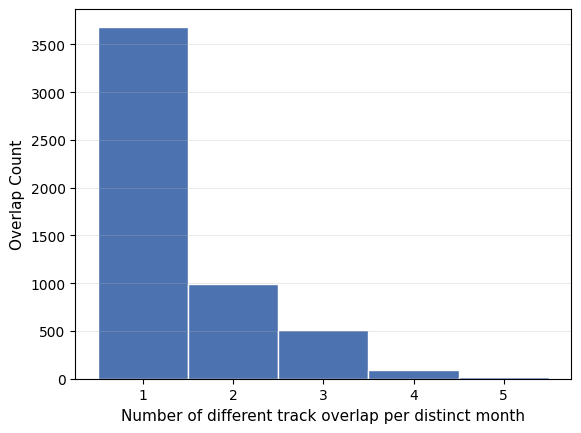

<module 'matplotlib.pyplot' from 'D:\\Projets\\env\\trackbuilder_env\\Lib\\site-packages\\matplotlib\\pyplot.py'>

In [15]:
overlap_small = overlap[['mmsi', 'num', 'month']].drop_duplicates()
print("Total number of distinct MMSI months : ", overlap_small.shape[0])
print("Number of overlapping months : ", overlap_small[overlap_small['num'] >= 2].shape[0])
print("Number of tracks with unlabelled segments overlapping (tracks have at least one assigned segment) : ", overlap_small[overlap_small['num'] >= 2]['mmsi'].nunique())
print("% of overlap ", (overlap_small[overlap_small['num'] >= 2].shape[0] / overlap_small.shape[0]) * 100)

clean_bar(overlap_small['num'], labels=['Number of different track overlap per distinct month', 'Overlap Count'], label="TRACK-OVERLAP", color="#4C72B0")

# bins = np.arange(-0.5, overlap_small['num'].max() + 1.5, 1)
# plt.hist(overlap_small['num'], bins=bins, rwidth=0.8)  # adds spacing
# plt.xticks(range(0, overlap_small['num'].max()+1))
# plt.grid(axis='y', alpha=0.3)

### Find the longest mmsi over time (from the match)

In [ ]:
err = df_GFW[df_GFW['mmsi'].isin(merged['mmsi'].unique())]
# err['month'] = err['month'].astype(str)
err = err[['mmsi','month', 'cell_ll_lat', 'cell_ll_lon']].drop_duplicates()
# err['total'] = err.groupby(['mmsi'])['mmsi'].transform('count')
ddd = merged[['mmsi', 'month', "shipid", "track_id", 'match_n_mmsi']].drop_duplicates()
eerrr = ddd.merge(err, on=['mmsi', 'month'])
eerrr.drop_duplicates(subset=['cell_ll_lat', 'cell_ll_lon'], inplace=True)
eerrr.groupby(['mmsi', 'month'])['mmsi'].count()


### Score computation
#### Consecutive months

In [16]:
df_temp = merged.copy()

### Compute number of correct pairs - total, by years, by mmsi ?
df_temp = df_temp[df_temp.groupby(['mmsi'])['month'].transform('nunique') >= 2][['mmsi', 'month', 'shipid', 'track_id']].drop_duplicates()

df_temp = df_temp.sort_values(['mmsi', 'month'])
# df_temp['month'] = pd.to_datetime(df_temp['month'])

In [8]:
# # Old computation way (1-to-1 link between ship dans mmsi)
# # compute difference in months within each mmsi
# df_temp['prev_month'] = df_temp.groupby('mmsi')['month'].shift(1)
# df_temp['prev_track_id'] = df_temp.groupby('mmsi')['track_id'].shift(1)
# df_temp['prev_ship'] = df_temp.groupby('mmsi')['shipid'].shift(1)
#
# # compute month difference
# df_temp['month_diff'] = (df_temp['month'] - df_temp['prev_month']).apply(lambda x: x.n if pd.notnull(x) else None)
#
# # condition: consecutive month AND same trackid
# count_consecutive = df_temp[(df_temp['month_diff'] == 1)].shape[0]
#
# count_true_consecutive = df_temp[(df_temp['month_diff'] == 1) & (df_temp['track_id'] == df_temp['prev_track_id'])].shape[0]
#
# print("Consecutive :", count_consecutive)
# print("Consecutive Valid:", count_true_consecutive)
# print("Consecutive %:", (count_true_consecutive/count_consecutive)*100)

Consecutive : 1978
Consecutive Valid: 1645
Consecutive %: 83.16481294236603


In [17]:

monthly = (
    df_temp.groupby(['mmsi', 'month'])
    .agg(
        track_id=('track_id', list),
        shipid=('shipid', list)
    )
)

monthly['month_value'] = monthly.index.get_level_values('month')

monthly_prev = (
    monthly.groupby(level='mmsi')
    .shift()
    .rename(columns={
        'track_id': 'prev_tracks',
        'shipid': 'prev_ships',
        'month_value': 'prev_month'
    })
)

df_temp = df_temp.merge(
    monthly_prev,
    left_on=['mmsi', 'month'],
    right_index=True,
    how='left'
)

df_temp['track_in_prev'] = df_temp.apply(
    lambda row: row['track_id'] in row['prev_tracks']
    if isinstance(row['prev_tracks'], list) else False,
    axis=1
)

df_temp['prev_ship'] = df_temp.groupby(['mmsi', 'track_id'])['shipid'].shift()

# compute month difference
df_temp['month_diff'] = (df_temp['month'] - df_temp['prev_month']).apply(lambda x: x.n if pd.notnull(x) else None)

# condition: consecutive month AND same trackid
count_consecutive = df_temp.loc[(df_temp['month_diff'] == 1), ['mmsi', 'month']].drop_duplicates()

count_true_consecutive = df_temp.loc[(df_temp['month_diff'] == 1) & df_temp['track_in_prev'], ['mmsi', 'month']].drop_duplicates()
count_invalid_consecutive = pd.concat([count_true_consecutive, count_consecutive]).drop_duplicates(keep=False)

print("Consecutive :", count_consecutive.shape[0])
print("Consecutive Valid:", count_true_consecutive.shape[0])
print("Consecutive Invalid:", count_invalid_consecutive.shape[0])
print("Consecutive %:", (count_true_consecutive.shape[0]/count_consecutive.shape[0])*100)

Consecutive : 460
Consecutive Valid: 421
Consecutive Invalid: 39
Consecutive %: 91.52173913043478


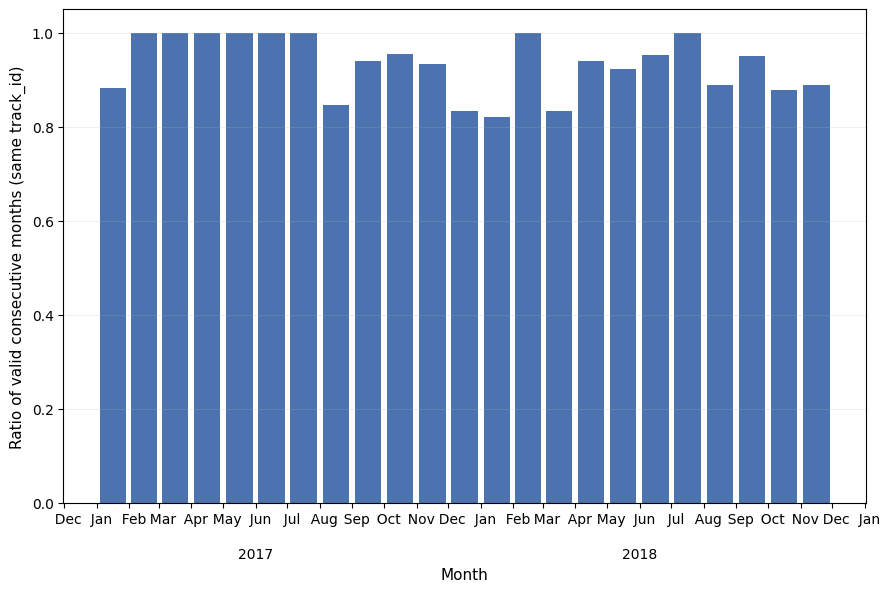

In [50]:
## Consecutive months by pairs
retest = df_temp.loc[(df_temp['month_diff'] == 1), ['mmsi', 'prev_month', 'month']].drop_duplicates().groupby(['prev_month', 'month']).count().reset_index()
retest_true = df_temp.loc[(df_temp['month_diff'] == 1) & df_temp['track_in_prev'], ['mmsi','prev_month', 'month']].drop_duplicates().groupby(['prev_month', 'month']).count().reset_index()

final = retest.merge(retest_true, on=['prev_month', 'month'])

final['prct'] = final['mmsi_y'] / final['mmsi_x']

final['prev_month'] = final['prev_month'].dt.to_timestamp()
final['month'] = final['month'].dt.to_timestamp()

# midpoint date of each month pair
x = final['prev_month'] + (final['month'] - final['prev_month']) / 2

special_bar(x, final['prct'], months, labels=['Month', 'Ratio of valid consecutive months (same track_id)'], label="TRACK-CONSECUTIVE", color="#4C72B0")

#### Difference of months between validation and tracks? Gaps

In [51]:
ref = df_temp.groupby('mmsi').apply(
        lambda g: pd.Series({
            'validation_gaps': (
                (g['month_diff'] != 1.0) &
                (g['month_diff'].notna())
            ).sum(),

            'track_diff': (
                (~g['track_in_prev']).sum() - 1
            ),

            'track_diff_on_consecutive': (
                (g['month_diff'] == 1.0) &
                (~g['track_in_prev'])
            ).sum(),

            'tot_validation_transitions': len(g) - 1
        })
    )

count_consecutive_gaps = df_temp[['mmsi', 'month', 'month_diff']].drop_duplicates()
#
# ref = count_consecutive_gaps.groupby('mmsi').apply(
#         lambda g: pd.Series({
#             'validation_gaps': (
#                 (g['month_diff'] != 1.0) &
#                 (g['month_diff'].notna())
#             ).sum(),
#             'tot_validation_transitions': len(g) - 1
#         })
#     )
# ref = ref.reset_index()
# ref

ref

C:\Users\virtu\AppData\Local\Temp\ipykernel_20432\29295560.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ref = df_temp.groupby('mmsi').apply(


,validation_gaps,track_diff,track_diff_on_consecutive,tot_validation_transitions
mmsi,,,,
231004000,1,2,1,3
231046000,0,0,0,1
231112000,2,3,1,8
231150000,1,2,1,5
231176000,0,0,0,2
...,...,...,...,...
331093000,2,1,0,9
331206000,1,2,1,3
331225000,2,3,1,7


<string>:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


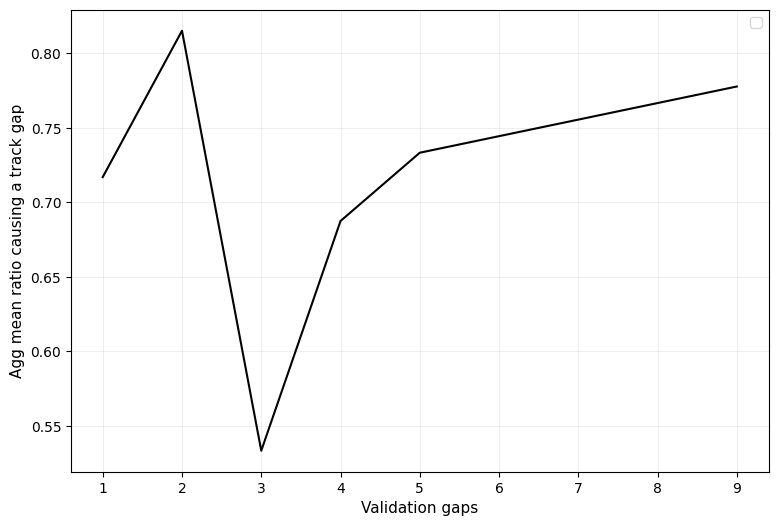

In [55]:
ratio =(ref['track_diff'] - ref['track_diff_on_consecutive']) / ref['validation_gaps']

plo = ratio.groupby(ref['validation_gaps']).mean()
evolution(plo, xlabel="Number of gaps", ylabel="Mean ratio of unassigned segments causing a gap", label="TRACK-GAPS")

<string>:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


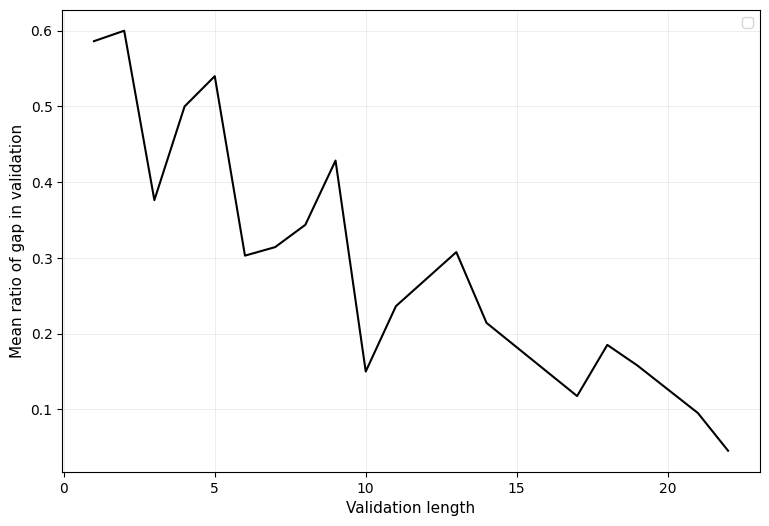

In [56]:
ratio =(ref['validation_gaps'] / ref['tot_validation_transitions'])

plo = ratio.groupby(ref['tot_validation_transitions']).mean()

plo2 = ref['validation_gaps'].groupby(ref['tot_validation_transitions']).count()

evolution(plo, xlabel="Validation length", ylabel="Mean ratio of gap in validation", label="TRACK-GAPS")

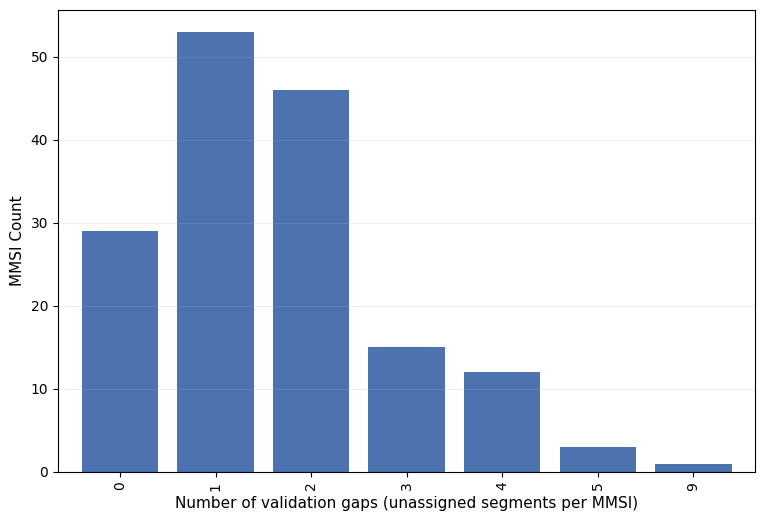

In [65]:
temp = ref.groupby('validation_gaps').size()
# temp = df_GFW.groupby('month').size()

clean_permonth(temp, labels=['Number of validation gaps (unassigned segments per MMSI)', 'MMSI Count'], label="TRACK-GAPS", color="#4C72B0")

#### Streaks

In [ ]:
# # Old way, when 1-1 link between shipid and mmsi
# ## Longest valid
# g = (df_temp['month_diff'] != df_temp['month_diff'].shift()).cumsum()
#
# streaks = (
#     df_temp[(df_temp['month_diff'] == 1) & (df_temp['track_id'] == df_temp['prev_track_id'])]
#     .groupby(['mmsi', g])
#     .size()
# )
#
# bins = np.arange(0.5, streaks.max() + 1.5, 1)
# plt.hist(streaks, bins=bins, rwidth=0.8)  # adds spacing
# plt.xticks(range(1, streaks.max()+1))
# plt.grid(axis='y', alpha=0.3)

# alone = df_GFW.loc[df_GFW['mmsi'].isin(streaks.reset_index()['mmsi'].unique().tolist()), ['mmsi', 'month']].drop_duplicates()

# # Old way max streak
# rrrr = streaks #+ 1 ## This is to find the number of months instead of the number of "jumps"
# reprcstrk = rrrr.reset_index().merge(alone.groupby('mmsi').count()-1, on='mmsi', how='inner')
# ### Max streak mean %
# print("Average max streak %")
# reprcstrk.groupby('mmsi').apply(lambda e : float((e[0].max() / e['month'].unique()))*100).describe()
# reprcstrk.groupby('mmsi').apply(lambda e : float((e[0].sum() / e['month'].unique()))*100).describe()

In [67]:
## Longest valid
# df_temp = df_temp[df_temp['mmsi']==231163000]
test = df_temp.groupby(['mmsi', 'month']).agg(
        month_diff=('month_diff', 'first'),
        track_in_prev=('track_in_prev', 'first')
    )

g = ((test['month_diff'] != 1 ) | ~(test['track_in_prev'])).cumsum()
# test = df_temp.loc[(df_temp['month_diff'] == 1) & df_temp['track_in_prev'], ['mmsi', 'month', 'month_diff']].drop_duplicates()

g_validation = (test['month_diff'] != 1 ).cumsum()

streaks_validation = (
    test
    .groupby(['mmsi', g_validation])
    .size()
) - 1

streaks_validation = streaks_validation.reset_index().merge(g_validation.reset_index(), on=["month_diff", "mmsi"]).rename(columns={"month_diff":"grp_validation"})

# streaks_cache = streaks

streaks = (
    test
    .groupby(['mmsi', g])
    .size()
) - 1

streaks = streaks.reset_index().merge(g.reset_index(), left_on=["level_1", "mmsi"], right_on=[0, "mmsi"]).rename(columns={"level_1":"grp_tb", "0_x":0}).drop(columns=["0_y"])
streaks_final = streaks.merge(streaks_validation, on=['mmsi', 'month'], how="inner").rename(columns={"0_x":"tb_streak", "0_y":"valid_streak"})
streaks_final

,mmsi,grp_tb,tb_streak,month,grp_validation,valid_streak
0,231004000,1,0,2018-07,1,0
1,231004000,2,0,2018-10,2,2
2,231004000,3,1,2018-11,2,2
3,231004000,3,1,2018-12,2,2
4,231046000,4,1,2018-01,3,1
...,...,...,...,...,...,...
844,331478000,429,6,2018-05,386,6
845,331479000,430,0,2017-01,387,0
846,331479000,431,1,2017-12,388,1
847,331479000,431,1,2018-01,388,1


In [68]:
streaks_final = streaks_final[['mmsi', 'tb_streak','valid_streak', 'grp_validation', 'grp_tb']].drop_duplicates()
streaks_final['prct'] = streaks_final['tb_streak'] / streaks_final['valid_streak']
streaks_final

,mmsi,tb_streak,valid_streak,grp_validation,grp_tb,prct
0,231004000,0,0,1,1,NaN
1,231004000,0,2,2,2,0.0
2,231004000,1,2,2,3,0.5
4,231046000,1,1,3,4,1.0
6,231112000,0,3,4,5,0.0
...,...,...,...,...,...,...
837,331478000,0,0,385,428,NaN
838,331478000,6,6,386,429,1.0
845,331479000,0,0,387,430,NaN
846,331479000,1,1,388,431,1.0


In [69]:
streak_tot = streaks_final.groupby(['mmsi','grp_validation']).agg(prct=("prct", 'sum'), streak=('valid_streak', 'first')).reset_index().groupby(['streak']).agg(prct=("prct", 'mean')).reset_index()
streak_tot = streak_tot[streak_tot['streak'] != 0]
streak_tot

,streak,prct
1,1,0.831169
2,2,0.857143
3,3,0.904762
4,4,0.964286
5,5,0.942857
6,6,0.944444
7,7,0.857143
8,8,1.000000
9,9,1.000000
10,11,0.939394


In [ ]:
streak_tot.index = streak_tot.pop('streak')

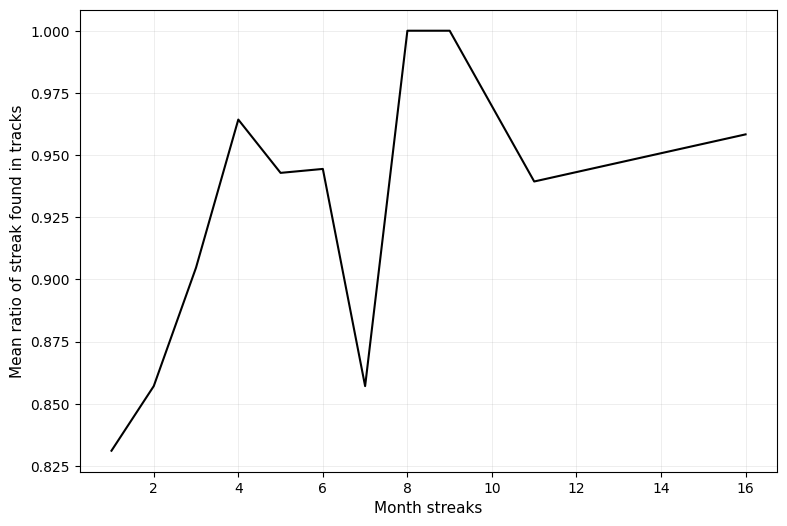

In [75]:
evolution(streak_tot, xlabel="Month streaks", ylabel="Mean ratio of streak found in tracks", label="TRACK-STREAK")

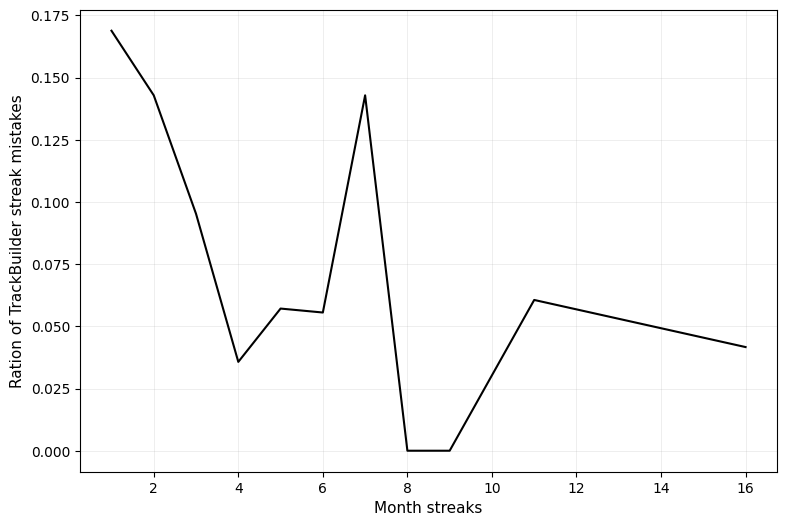

In [76]:
evolution(1 - streak_tot, xlabel="Month streaks", ylabel="Ration of TrackBuilder streak mistakes", label="TRACK-STREAK")

##### Max month streak

In [77]:
streak_max = streaks_final.groupby(['mmsi','grp_validation']).agg(prct=("prct", 'max'), streak=('valid_streak', 'first')).reset_index().groupby(['streak']).agg(prct=("prct", 'mean')).reset_index()
streak_max = streak_max[streak_max['streak'] != 0]
streak_max

,streak,prct
1,1,0.831169
2,2,0.857143
3,3,0.888889
4,4,0.946429
5,5,0.885714
6,6,0.944444
7,7,0.714286
8,8,1.000000
9,9,1.000000
10,11,0.878788


In [78]:
streak_max.index = streak_max.pop('streak')

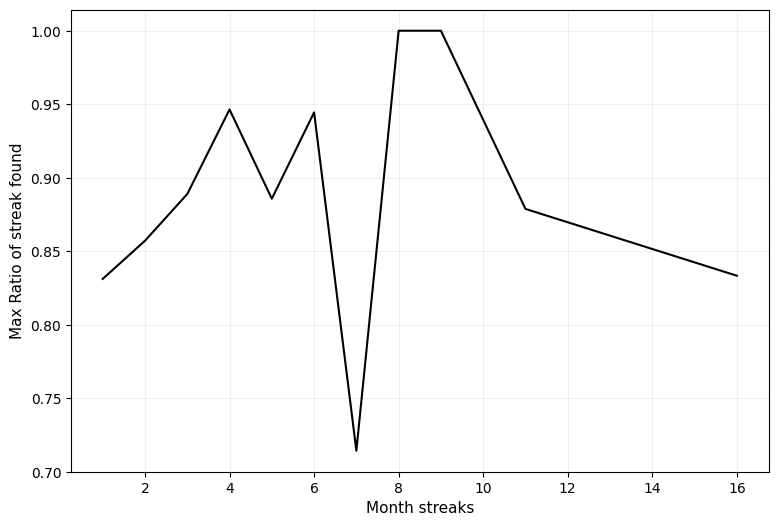

In [79]:
evolution(streak_max, xlabel="Month streaks", ylabel="Max Ratio of streak found", label="TRACK-STREAK")

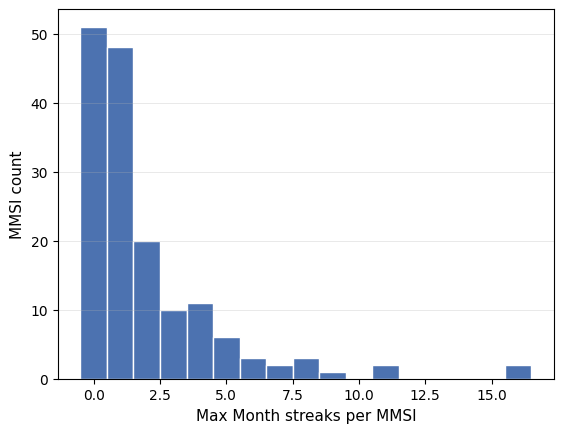

<module 'matplotlib.pyplot' from 'D:\\Projets\\env\\trackbuilder_env\\Lib\\site-packages\\matplotlib\\pyplot.py'>

In [82]:
maxx = streaks.reset_index()

maxx = maxx.loc[maxx.groupby('mmsi')[0].idxmax()].drop_duplicates()[0]

clean_bar(maxx, labels=['Max Month streaks per MMSI', 'MMSI count'], label="TRACK-STREAK", color="#4C72B0")

## Visualize MMSI

In [ ]:
mmsi = 231189000
# track_ids = [188, 201, 576, 876, 1305, 1320
track_ids =merged[merged['mmsi']==mmsi]['track_id'].unique().tolist()

In [ ]:
merged[merged['mmsi']==mmsi]

In [ ]:
tracks[tracks['track_id'].isin(track_ids)]

In [ ]:
# display(merged[merged['mmsi']==mmsi])
display(merged[merged['mmsi']==mmsi][['mmsi', 'month','track_id', 'shipid', 'match_n_mmsi', 'astd_n_ship', 'gfw_n_mmsi']].drop_duplicates())
data[data['mmsi']==mmsi]

In [ ]:
col_lat_astd = 'latitude'
col_lon_astd = 'longitude'

col_lat_gfw = 'cell_ll_lat'
col_lon_gfw = 'cell_ll_lon'


df1 = build_tracks[(build_tracks['track_id'].isin(track_ids))]#& (build_tracks['month']=='2020-07')]
df2 = df_GFW[(df_GFW['mmsi']==mmsi)]# & (df_GFW['month']=='2020-03')]
df2 = df2.drop_duplicates(subset=[col_lon_gfw, col_lat_gfw, 'month'])

# df2 = df2.sample(frac=0.6)

display(df2)
df1

In [ ]:
import plotly.express as px
import plotly.io as pio
import plotly.graph_objects as go

pio.renderers.default = "browser"
# pio.renderers.default = "notebook"

months = (
    pd.concat([
        df1['month'].dt.to_timestamp(),
        df2['month'].dt.to_timestamp()
    ])
    .dt.strftime("%Y-%m")
    .unique()
)
month_colors = px.colors.qualitative.Plotly  # 12 colors

color_map = {m: month_colors[i % len(month_colors)] for i, m in enumerate(sorted(months))}

# Generate the figure
# fig2 = tb.plot_ship_tracks(
#     df1,
#     track_ids=track_ids,
#     show_points=True,
#     show_start_end=True,
#     map_style="open-street-map"
# )

fig2 = go.Figure()

for (month, track_id), df_month in df1.groupby(['month', 'track_id']):
    df_month = df_month.sort_values('date_time_utc')
    month = month.strftime("%Y-%m")

    fig2.add_trace(go.Scattermap(
        lon=df_month[col_lon_astd],
        lat=df_month[col_lat_astd],
        mode="lines+markers",
        name=f"TRACK {track_id} {month}",
        line=dict(color=color_map[month], width=2),
        marker=dict(size=6),
        customdata=df_month['date_time_utc'],
        hovertemplate=(
            "Date: %{customdata}<br>"
            "Lat: %{lat}<br>"
            "Lon: %{lon}<extra></extra>"
        )
    ))

# requested_ids_str = set(str(x) for x in track_ids)
# tt_subset = tracks[tracks["track_id"].astype(str).isin(requested_ids_str)].copy()
#
#
# fig2 = tb.plot_individual_track(
#     track_id=track_ids[0],
#     track_table=tt_subset,
#     astd_data=df_ASTD,
#     show_segments=True
# )


In [ ]:

for month, month_df in df2.groupby("month"):
    lons_all = []
    lats_all = []
    hover_text = []
    month = month.strftime("%Y-%m")

    for _, row in month_df.iterrows():
        lon0 = row["cell_ll_lon"]
        lat0 = row["cell_ll_lat"]

        lons_all += [lon0, lon0 + 0.1, lon0 + 0.1, lon0, lon0, None]
        lats_all += [lat0, lat0, lat0 + 0.1, lat0 + 0.1, lat0, None]

        hover_text += [f"Month: {month}<br>Day: {row['date']}"]*6 + [None]

    fig2.add_trace(go.Scattermap(
        lon=lons_all,
        lat=lats_all,
        mode="lines",
        line=dict(color=color_map[month], width=1),
        text=hover_text,
        hovertemplate="%{text}<extra></extra>",
        showlegend=True,
        name=f"GFW {month}"
    ))

# for month, month_df in df2.groupby("month"):
#     month_df = month_df.sort_index()  # ensure order
#
#     fig2.add_trace(go.Scattermapbox(
#         lon=month_df["cell_ll_lon"] + 0.05,
#         lat=month_df["cell_ll_lat"] + 0.05,
#         mode="lines+markers",
#         line=dict(color=color_map[month], width=2),
#         marker=dict(size=6),
#         text=[f"Month: {month}<br>Day: {d}" for d in month_df["date"]],
#         hovertemplate="%{text}<extra></extra>",
#         name=f"{month}"
#     ))



fig2.update_layout(
    map=dict(
        style="open-street-map",
        zoom=3,
        center=dict(lat=df1["latitude"].mean(),
                    lon=df1["longitude"].mean())
    ),
    title=f"{mmsi} for {track_ids}"
)

# tb.export_figure(fig2, f"outputs/output_{track_ids}.html")
# tb.export_figure(fig2, f"outputs/output_{track_ids}.pdf")

fig2.show()

## TrackBuilder Logs analysis

In [11]:
tracks_log.groupby('reason').size()

reason
already_assigned             318
distance_window          2102895
flagname_mismatch            971
iceclass_mismatch           2372
sizegroup_gt_mismatch        936
speed_cap                   4330
time_window                57921
dtype: int64

In [12]:
mask1 = merged.groupby(['mmsi'])['month'].transform('nunique') >= 2
mask = merged.groupby(['mmsi'])['track_id'].transform('nunique') > 1

df = merged[mask1 & mask][['mmsi', 'month', 'shipid', 'track_id']].drop_duplicates()
del mask1, mask
df

,mmsi,month,shipid,track_id
0,273217010,2020-04,1952,1898
6378,276806000,2020-10,641,2361
13847,258535000,2020-10,1219,2450
21552,273451570,2020-09,324,631
27852,277558000,2020-11,2082,1689
...,...,...,...,...
14323422,251153000,2020-06,1557,664
14324432,277558000,2019-05,15527,1045
14324835,259616000,2019-08,21852,1210
14324977,231189000,2020-05,22009,2153


In [13]:
# Check concurrent month if they have different track_id (why are they on different ?)

df = df.sort_values(['mmsi', 'month'])
# df['month'] = pd.to_datetime(df['month'])
# compute difference in months within each mmsi
# previous values per mmsi
df['prev_date'] = df.groupby('mmsi')['month'].shift(1)
df['prev_track_id'] = df.groupby('mmsi')['track_id'].shift(1)
df['prev_ship'] = df.groupby('mmsi')['shipid'].shift(1)

# compute month difference
df['month_diff'] = (
    df['month'] - df['prev_date']
).apply(lambda x: x.n if pd.notnull(x) else None)

# condition: consecutive month AND trackid different
df['match'] = (df['month_diff'] == 1) & (df['track_id'] != df['prev_track_id'])
df

,mmsi,month,shipid,track_id,prev_date,prev_track_id,prev_ship,month_diff,match
11686551,231004000,2019-01,2487,124,NaT,NaN,NaN,NaN,False
10789591,231004000,2019-06,2813,776,2019-01,124.0,2487.0,5.0,False
12197898,231004000,2019-10,2800,776,2019-06,776.0,2813.0,4.0,False
12011821,231004000,2019-11,2731,776,2019-10,776.0,2800.0,1.0,False
12506959,231004000,2019-12,2476,776,2019-11,776.0,2731.0,1.0,False
...,...,...,...,...,...,...,...,...,...
10290186,331746000,2020-07,2135,1911,2020-06,1911.0,2602.0,1.0,False
11244541,331746000,2020-08,2652,1911,2020-07,1911.0,2135.0,1.0,False
8970767,331746000,2020-09,2879,1911,2020-08,1911.0,2652.0,1.0,False
8335042,331746000,2020-10,2872,2559,2020-09,1911.0,2879.0,1.0,True


In [14]:
df[df["match"]==True]

,mmsi,month,shipid,track_id,prev_date,prev_track_id,prev_ship,month_diff,match
1394392,231066000,2019-06,3187,1074,2019-05,749.0,3088.0,1.0,True
4218984,231066000,2019-09,4037,1385,2019-08,1074.0,4107.0,1.0,True
3625857,231066000,2020-03,3403,1913,2020-02,1657.0,2835.0,1.0,True
384802,231066000,2020-07,1467,2301,2020-06,1913.0,1204.0,1.0,True
11025546,231150000,2020-06,3947,2188,2020-05,695.0,981.0,1.0,True
...,...,...,...,...,...,...,...,...,...
12926385,331225000,2020-12,5003,2778,2020-11,2707.0,5633.0,1.0,True
8788088,331428000,2019-12,3197,1699,2019-11,1273.0,3577.0,1.0,True
11293676,331549000,2020-02,3236,1809,2020-01,1057.0,3034.0,1.0,True
8335042,331746000,2020-10,2872,2559,2020-09,1911.0,2879.0,1.0,True


In [15]:
merged_bis = df[df["match"]==True].merge(tracks_log, left_on=['prev_ship', 'shipid', 'prev_date'], right_on=['from_shipid', 'to_shipid', 'from_month'],how='left')
merged_bis

,mmsi,month,shipid,track_id,prev_date,prev_track_id,prev_ship,month_diff,match,match_id,from_shipid,to_shipid,from_month,to_month,stage,reason,dt_hours,distance_km_fd,implied_v_kmh
0,231066000,2019-06,3187,1074,2019-05,749.0,3088.0,1.0,True,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
1,231066000,2019-09,4037,1385,2019-08,1074.0,4107.0,1.0,True,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
2,231066000,2020-03,3403,1913,2020-02,1657.0,2835.0,1.0,True,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
3,231066000,2020-07,1467,2301,2020-06,1913.0,1204.0,1.0,True,1204→1467,1204.0,1467.0,2020-06,2020-07,filter,time_window,24.312778,13.740834,NaN
4,231150000,2020-06,3947,2188,2020-05,695.0,981.0,1.0,True,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
328,331225000,2020-12,5003,2778,2020-11,2707.0,5633.0,1.0,True,5633→5003,5633.0,5003.0,2020-11,2020-12,filter,time_window,34.360556,35.662460,NaN
329,331428000,2019-12,3197,1699,2019-11,1273.0,3577.0,1.0,True,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
330,331549000,2020-02,3236,1809,2020-01,1057.0,3034.0,1.0,True,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
331,331746000,2020-10,2872,2559,2020-09,1911.0,2879.0,1.0,True,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
merged_bis.groupby('reason').size()

reason
already_assigned     28
speed_cap           117
time_window          19
dtype: int64

In [13]:
merged_bis[merged_bis['reason']=="speed_cap"]

,mmsi,month,shipid,track_id,prev_date,prev_track_id,prev_ship,month_diff,match,match_id,from_shipid,to_shipid,from_month,to_month,stage,reason,dt_hours,distance_km_fd,implied_v_kmh


In [17]:
temp = merged_bis[merged_bis['match_id'].isna()]#.sample(10)
temp

,mmsi,month,shipid,track_id,prev_date,prev_track_id,prev_ship,month_diff,match,match_id,from_shipid,to_shipid,from_month,to_month,stage,reason,dt_hours,distance_km_fd,implied_v_kmh
0,231066000,2019-06,3187,1074,2019-05,749.0,3088.0,1.0,True,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
1,231066000,2019-09,4037,1385,2019-08,1074.0,4107.0,1.0,True,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
2,231066000,2020-03,3403,1913,2020-02,1657.0,2835.0,1.0,True,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
4,231150000,2020-06,3947,2188,2020-05,695.0,981.0,1.0,True,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
6,231164000,2020-07,1897,687,2020-06,616.0,2140.0,1.0,True,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
324,331206000,2020-11,4746,2699,2020-10,1906.0,2907.0,1.0,True,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
325,331225000,2020-02,2289,1827,2020-01,712.0,2096.0,1.0,True,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
329,331428000,2019-12,3197,1699,2019-11,1273.0,3577.0,1.0,True,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
330,331549000,2020-02,3236,1809,2020-01,1057.0,3034.0,1.0,True,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
temp[temp['shipid']==829]

,mmsi,month,shipid,track_id,prev_date,prev_track_id,prev_ship,month_diff,match,match_id,from_shipid,to_shipid,from_month,to_month,stage,reason,dt_hours,distance_km_fd,implied_v_kmh


In [16]:
#
dates = set(temp["prev_date"].unique().astype(str).tolist() + temp["month"].unique().astype(str).tolist())

temp_astd = df_ASTD[df_ASTD['month'].dt.strftime("%Y-%m").isin(dates)].copy()

In [74]:
results = []

for i, line in tqdm(
        enumerate(temp.itertuples(index=False)),
        total=len(temp)
    ):
    out, log = tb.find_track_candidates(int(line['prev_ship']), line['prev_date'].strftime("%Y-%m"), temp_astd, return_logs=True,
            max_time_gap_hours = 24,
            max_distance_km = 400,
            matching_strategy = "balanced",
            w_time = 0.1,
            w_dist = 0.4,
            w_speed = 0.5,
            gap_days_no_penalty = 3.0,
            gap_penalty_per_day = 0.05)
    results.append((line, out, log))

  0%|          | 0/81 [00:00<?, ?it/s]

TypeError: tuple indices must be integers or slices, not str

#### New test

In [75]:
temp_astd["month_str"] = temp_astd["month"].dt.strftime("%Y-%m")

# Build lookup dictionary: month -> dataframe
astd_by_month = {
    k: v
    for k, v in temp_astd.groupby("month_str")
}

In [76]:
import pandas as pd

# Precompute cache once
cache = {}

for line in temp.itertuples(index=False):
    d2 = [str(line.prev_date), str(line.month)]

    key = tuple(sorted(d2))

    if key not in cache:
        cache[key] = pd.concat(
            [astd_by_month[d] for d in d2 if d in astd_by_month],
            ignore_index=True
        )
del astd_by_month

In [77]:
from joblib import Parallel, delayed

def process_line(i, line, cache):
    d2 = [str(line.prev_date), str(line.month)]
    #
    key = tuple(sorted(d2))
    temp_bis = cache[key]

    # print("loading..", i)

    out, log = tb.find_track_candidates(
        int(line.prev_ship),
        line.prev_date.strftime("%Y-%m"),
        temp_bis,
        return_logs=True,
        max_time_gap_hours=24,
        max_distance_km=400,
        matching_strategy="balanced",
        w_time=0.03,
        w_dist=0.3,
        w_speed=0.67,
        gap_days_no_penalty=3.0,
        gap_penalty_per_day=0.05
    )

    return (line, out, log)

from tqdm.auto import tqdm

results = Parallel(n_jobs=-1, backend="threading")(
    delayed(process_line)(i, line, cache)
    for i, line in tqdm(
        enumerate(temp.itertuples(index=False)),
        total=len(temp)
    )
)

  0%|          | 0/81 [00:00<?, ?it/s]

Data after cleaning:
  Date range: 2019-08-01 00:00:01+00:00 to 2019-09-30 23:59:57+00:00
  Ship types: ['fishing vessels']
Data after cleaning:
  Unique ships: 628
  Date range: 2020-04-01 00:00:02+00:00 to 2020-05-31 23:59:58+00:00


D:\Projets\clone\TrackBuilder\track_builder\core\track_helpers.py:231: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['period_month'] = df['date_time_utc'].dt.to_period('M')


  Ship types: ['fishing vessels']
  Unique ships: 620


D:\Projets\clone\TrackBuilder\track_builder\core\track_helpers.py:231: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['period_month'] = df['date_time_utc'].dt.to_period('M')


...

Creating segments for 661 unique ship-months (segments)...
Successfully created 666 monthly segments.
Sample segment: fishing vessels|russia|fs ice class 1c|< 1000 gt in 2019-08
Successfully created 661 monthly segments.
Sample segment: fishing vessels|russia|fs ice class 1c|< 1000 gt in 2019-08
Successfully created 615 monthly segments.
Sample segment: fishing vessels|iceland|fs ice class 1c|1000 - 4999 gt in 2019-12
Creating segments for 658 unique ship-months (segments)...
Successfully created 666 monthly segments.
Sample segment: fishing vessels|russia|fs ice class 1c|< 1000 gt in 2019-08
Successfully created 650 monthly segments.
Sample segment: fishing vessels|russia|fs ice class 1c|< 1000 gt in 2019-09
Creating segments for 608 unique ship-months (segments)...
Data after cleaning:
  Date range: 2020-03-01 00:00:01+00:00 to 2020-04-30 23:59:57+00:00
  Ship types: ['fishing vessels']
  Unique ships: 605


D:\Projets\clone\TrackBuilder\track_builder\core\track_helpers.py:231: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['period_month'] = df['date_time_utc'].dt.to_period('M')


Data after cleaning:
  Date range: 2020-02-01 00:00:01+00:00 to 2020-03-31 23:59:57+00:00
  Ship types: ['fishing vessels']
  Unique ships: 601


D:\Projets\clone\TrackBuilder\track_builder\core\track_helpers.py:231: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['period_month'] = df['date_time_utc'].dt.to_period('M')


Creating segments for 617 unique ship-months (segments)...
Creating segments for 622 unique ship-months (segments)...
Successfully created 658 monthly segments.
Sample segment: fishing vessels|norway|fs ice class 1c|1000 - 4999 gt in 2020-08
Successfully created 608 monthly segments.
Sample segment: fishing vessels|russia|fs ice class 1c|< 1000 gt in 2019-04
Successfully created 657 monthly segments.
Sample segment: fishing vessels|norway|fs ice class 1b|1000 - 4999 gt in 2020-09
Successfully created 661 monthly segments.
Sample segment: fishing vessels|russia|fs ice class 1c|< 1000 gt in 2019-08
Successfully created 661 monthly segments.
Sample segment: fishing vessels|russia|fs ice class 1c|< 1000 gt in 2019-08
Successfully created 658 monthly segments.
Sample segment: fishing vessels|norway|fs ice class 1c|1000 - 4999 gt in 2020-08
Successfully created 649 monthly segments.
Sample segment: fishing vessels|iceland|fs ice class 1c|< 1000 gt in 2019-06
Successfully created 617 monthly 

In [78]:
clean_results = []

for meta, df1, df2 in results:
    # meta_clean = {
    #     "mmsi": meta.mmsi,
    #     "month": str(meta.month),
    #     "shipid": meta.shipid,
    #     "track_id": meta.track_id,
    #     "prev_date": str(meta.prev_date),
    #     "prev_track_id": meta.prev_track_id,
    #     "prev_ship": meta.prev_ship,
    #     "month_diff": meta.month_diff,
    #     "match": meta.match
    # }
    meta_clean = pd.DataFrame([meta])
    clean_results.append((meta_clean, df1.copy(), df2.copy()))


import pickle

with open("results_better.pkl", "wb") as f:
    pickle.dump(clean_results, f)

In [17]:
import pickle

with open("results_better.pkl", "rb") as f:
    clean_results = pickle.load(f)


In [18]:
truth = clean_results[0][1][clean_results[0][1]["segment_id"] == int(clean_results[0][0]['shipid'].iloc[0])][['match_score_simple', 'distance_km_fd', 'implied_v_kmh', 'dt_hours']]

first = clean_results[0][1].iloc[0][['match_score_simple', 'distance_km_fd', 'implied_v_kmh', 'dt_hours']]


In [19]:
final_result = []

for i, (source, df, _) in enumerate(clean_results):
    df['id'] = int(source['prev_ship'].iloc[0])
    df['id_truth'] = int(source['shipid'].iloc[0])
    df['id_month'] = source['prev_date'].astype(str).iloc[0]
    final_result.append(df)

final_result = pd.concat(final_result).reset_index(drop=True)
final_result

,month,segment_id,match_score_simple,distance_km_fd,implied_v_kmh,dt_hours,id,id_truth,id_month
0,2020-07,3655,0.105039,3.300948,4.245592,0.777500,2140,1897,2020-06
1,2020-07,1897,0.175928,1.822525,7.282010,0.250278,2140,1897,2020-06
2,2020-07,5536,0.318758,159.318771,7.166299,22.231667,2140,1897,2020-06
3,2019-11,4027,0.388165,11.852119,0.074897,158.245000,2604,8155,2019-10
4,2019-11,8155,0.975667,0.124639,0.000369,337.669444,2604,8155,2019-10
...,...,...,...,...,...,...,...,...,...
266,2020-03,2978,0.141351,18.699926,5.130686,3.644722,2392,2883,2020-02
267,2020-03,2783,0.152708,19.933325,5.570129,3.578611,2392,2883,2020-02
268,2020-03,2883,0.497938,68.416275,18.471471,3.703889,2392,2883,2020-02
269,2020-04,2125,0.102104,1.124759,4.217847,0.266667,105,1785,2020-03


In [26]:
final_result.groupby(['id', 'month']).size()

id    month  
21    2019-09    2
76    2020-08    2
105   2020-04    2
386   2020-12    2
666   2020-06    3
                ..
4540  2019-09    3
4603  2019-09    5
4619  2019-09    5
4643  2019-09    2
4677  2019-07    3
Length: 81, dtype: int64

In [21]:
final_result[final_result['month'].isna()].shape[0]

0

In [22]:
cols = ['match_score_simple', 'distance_km_fd', 'implied_v_kmh', 'dt_hours']
rows = []

is_good = 0
or_1 = 0
not_found = 0
for i, (source, df, _) in enumerate(clean_results):
    print("Checking :", i)

    if df.shape[0] < 2 :
        print("Number of candidates insuficient")
        or_1+=1
        continue

    is_shipid = df[df["segment_id"] == int(source['shipid'].iloc[0])][cols]

    if is_shipid.shape[0] == 0:
        print("Valid shipid is inconsistent")
        not_found +=1
        continue

    is_good +=1
    truth = is_shipid.iloc[0]
    first = df.iloc[0][cols]
    
    diff = first - truth

    row = {}
    row["run"] = i

    for c in cols:
        row[f"truth_{c}"] = truth[c]
        row[f"first_{c}"] = first[c]
        row[f"diff_{c}"] = diff[c]

    rows.append(row)
comp = pd.DataFrame(rows)
print(is_good)
print(or_1)
print(not_found)


Checking : 0
Checking : 1
Checking : 2
Checking : 3
Checking : 4
Checking : 5
Checking : 6
Checking : 7
Checking : 8
Checking : 9
Checking : 10
Checking : 11
Checking : 12
Checking : 13
Checking : 14
Checking : 15
Checking : 16
Valid shipid is inconsistent
Checking : 17
Checking : 18
Checking : 19
Checking : 20
Checking : 21
Checking : 22
Checking : 23
Checking : 24
Checking : 25
Checking : 26
Checking : 27
Checking : 28
Checking : 29
Checking : 30
Checking : 31
Valid shipid is inconsistent
Checking : 32
Checking : 33
Valid shipid is inconsistent
Checking : 34
Checking : 35
Checking : 36
Checking : 37
Checking : 38
Checking : 39
Checking : 40
Checking : 41
Checking : 42
Checking : 43
Checking : 44
Checking : 45
Checking : 46
Checking : 47
Checking : 48
Checking : 49
Checking : 50
Valid shipid is inconsistent
Checking : 51
Checking : 52
Valid shipid is inconsistent
Checking : 53
Checking : 54
Checking : 55
Valid shipid is inconsistent
Checking : 56
Checking : 57
Checking : 58
Valid ship

In [40]:
clean_results[39][1]

,month,segment_id,match_score_simple,distance_km_fd,implied_v_kmh,dt_hours,id,id_truth,id_month
0,2020-05,829,0.524468,2.226767,21.842949,0.101944,3144,829,2020-04


In [23]:
cols = ["diff_"+c for c in cols]

report = pd.DataFrame({
    "mean_abs_error": comp[cols].abs().mean(),
    "std_error": comp[cols].std(),
    "bias": comp[cols].mean()
}).sort_values("mean_abs_error", ascending=False)

report

,mean_abs_error,std_error,bias
diff_dt_hours,18.661555,80.273174,-14.785876
diff_distance_km_fd,9.799423,25.833113,3.196295
diff_implied_v_kmh,3.137613,3.449720,-3.118733
diff_match_score_simple,0.122759,0.262303,-0.122759


In [24]:
from scipy.stats import zscore

comp_z = comp[cols].apply(zscore)

report_z = pd.DataFrame({
    "mean_abs_error": comp_z.abs().mean(),
    "std_error": comp_z.std(),
    "bias": comp_z.mean()
}).sort_values("mean_abs_error", ascending=False)

report_z

,mean_abs_error,std_error,bias
diff_implied_v_kmh,0.724405,1.007018,-2.467162e-17
diff_match_score_simple,0.467276,1.007018,-1.233581e-17
diff_distance_km_fd,0.463436,1.007017,6.622738e-09
diff_dt_hours,0.378608,1.007018,0.000000e+00


### Generate candidates of a particular shipid

In [41]:
months_selec = ["2020-04", "2020-05"]

In [42]:
temp_astd = df_ASTD[df_ASTD['month'].dt.strftime("%Y-%m").isin(months_selec)].copy()
temp_astd

,shipid,date_time_utc,flagname,iceclass,astd_cat,sizegroup_gt,dist_nextpoint,sec_nextpoint,longitude,latitude,month,date
53998902,1978,2020-04-01 00:00:02+00:00,Norway,FS Ice Class 1C,Fishing vessels,1000 - 4999 GT,105.989922,362,17.611404,69.934097,2020-04,2020-04-01 00:00:00+00:00
53998906,479,2020-04-01 00:00:04+00:00,Iceland,FS Ice Class 1B,Fishing vessels,1000 - 4999 GT,1.405078,279,-21.931913,64.159637,2020-04,2020-04-01 00:00:00+00:00
53998907,954,2020-04-01 00:00:06+00:00,Iceland,FS Ice Class 1C,Fishing vessels,1000 - 4999 GT,829.520996,360,-21.591827,63.356594,2020-04,2020-04-01 00:00:00+00:00
53998908,1728,2020-04-01 00:00:08+00:00,Russia,FS Ice Class 1C,Fishing vessels,1000 - 4999 GT,2.867218,182,14.807855,77.612000,2020-04,2020-04-01 00:00:00+00:00
53998910,3144,2020-04-01 00:00:09+00:00,Russia,FS Ice Class 1C,Fishing vessels,1000 - 4999 GT,517.446228,380,16.703386,74.288147,2020-04,2020-04-01 00:00:00+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...
61530551,1730,2020-05-31 23:59:42+00:00,Germany,FS Ice Class 1B,Fishing vessels,1000 - 4999 GT,2226.804932,370,9.632876,66.549248,2020-05,2020-05-31 00:00:00+00:00
61530553,511,2020-05-31 23:59:43+00:00,Iceland,FS Ice Class 1C,Fishing vessels,< 1000 GT,0.557000,59,-22.418909,63.839699,2020-05,2020-05-31 00:00:00+00:00
61530558,2248,2020-05-31 23:59:53+00:00,Russia,FS Ice Class II,Fishing vessels,1000 - 4999 GT,1754.107056,361,27.455641,71.938255,2020-05,2020-05-31 00:00:00+00:00
61530561,733,2020-05-31 23:59:55+00:00,Norway,FS Ice Class 1C,Fishing vessels,1000 - 4999 GT,496.023987,396,30.124743,72.330284,2020-05,2020-05-31 00:00:00+00:00


In [43]:
shipid_from = 3144

out, log = tb.find_track_candidates(shipid_from, months_selec[0], temp_astd, return_logs=True,
        max_time_gap_hours = 24,
        max_distance_km = 400,
        matching_strategy = "balanced",
        w_time = 0.03,
        w_dist = 0.3,
        w_speed = 0.67,
        gap_days_no_penalty = 3.0,
        gap_penalty_per_day = 0.05)
out

Data after cleaning:
  Date range: 2020-04-01 00:00:02+00:00 to 2020-05-31 23:59:58+00:00
  Ship types: ['fishing vessels']
  Unique ships: 620


D:\Projets\clone\TrackBuilder\track_builder\core\track_helpers.py:231: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['period_month'] = df['date_time_utc'].dt.to_period('M')


Creating segments for 638 unique ship-months (segments)...
Successfully created 638 monthly segments.
Sample segment: fishing vessels|russia|fs ice class 1b|1000 - 4999 gt in 2020-04


,month,segment_id,match_score_simple,distance_km_fd,implied_v_kmh,dt_hours
0,2020-05,829,0.524468,2.226767,21.842949,0.101944


In [44]:
log

,match_id,from_shipid,to_shipid,from_month,to_month,stage,reason,dt_hours,distance_km_fd,implied_v_kmh
0,3144→8,3144,8,2020-04,2020-05,filter,distance_window,0.048333,742.335571,NaN
1,3144→1785,3144,1785,2020-04,2020-05,filter,distance_window,0.049444,1924.756348,NaN
2,3144→1759,3144,1759,2020-04,2020-05,filter,distance_window,0.049444,1510.233032,NaN
3,3144→1761,3144,1761,2020-04,2020-05,filter,distance_window,0.049722,1949.007812,NaN
4,3144→1818,3144,1818,2020-04,2020-05,filter,distance_window,0.050556,1945.876709,NaN
...,...,...,...,...,...,...,...,...,...,...
319,3144→2249,3144,2249,2020-04,2020-05,filter,speed_cap,0.220000,235.344788,1069.749035
320,3144→2248,3144,2248,2020-04,2020-05,filter,speed_cap,0.220000,298.027283,1354.669467
321,3144→2265,3144,2265,2020-04,2020-05,filter,speed_cap,0.223889,242.244568,1081.985663
322,3144→2281,3144,2281,2020-04,2020-05,filter,speed_cap,0.231389,340.429474,1471.243825


In [45]:
# merged[['mmsi', 'month', 'shipid', 'track_id']].drop_duplicates()
tracks_log[tracks_log['from_shipid']==shipid_from]

,match_id,from_shipid,to_shipid,from_month,to_month,stage,reason,dt_hours,distance_km_fd,implied_v_kmh
628293,3144→3753,3144,3753,2019-06,2019-07,filter,distance_window,0.171389,2094.928467,NaN
628294,3144→4676,3144,4676,2019-06,2019-07,filter,distance_window,0.171667,2528.142090,NaN
628295,3144→5475,3144,5475,2019-06,2019-07,filter,distance_window,0.172222,2351.957520,NaN
628296,3144→2158,3144,2158,2019-06,2019-07,filter,distance_window,0.172500,2066.505127,NaN
628297,3144→11712,3144,11712,2019-06,2019-07,filter,distance_window,0.172500,510.088409,NaN
...,...,...,...,...,...,...,...,...,...,...
1952647,3144→6544,3144,6544,2020-02,2020-03,filter,sizegroup_gt_mismatch,141.049722,0.510938,0.003622
1952648,3144→6426,3144,6426,2020-02,2020-03,filter,sizegroup_gt_mismatch,321.059167,0.640497,0.001995
1952649,3144→13545,3144,13545,2020-02,2020-03,filter,sizegroup_gt_mismatch,593.473889,0.334112,0.000563
1952650,3144→16061,3144,16061,2020-02,2020-03,filter,sizegroup_gt_mismatch,761.400000,1.168229,0.001534


In [46]:
tracks[tracks['segment_id']==3144]

,month,segment_id,track_id
2090,2019-06,3144,504
5566,2020-04,3144,900
6345,2020-02,3144,1036


In [47]:
tracks[tracks['track_id']==900]

,month,segment_id,track_id
5559,2019-09,4367,900
5560,2019-10,5250,900
5561,2019-11,3404,900
5562,2019-12,2732,900
5563,2020-01,2597,900
5564,2020-02,2789,900
5565,2020-03,3350,900
5566,2020-04,3144,900
5567,2020-05,829,900
5568,2020-06,771,900


In [45]:
## Visualization
import plotly.io as pio
pio.renderers.default = "browser"

shipids = [3088, 2636, 2542, 3187]

to_plot = df_ASTD[(df_ASTD['shipid'].isin(shipids)) & (df_ASTD['month'].astype(str).isin(months_selec))].copy()
to_plot['track_id'] = to_plot['shipid']

fig = tb.plot_ship_tracks(to_plot, shipids, show_start_end=True)
fig.show()

In [69]:
### For speed cap, compare last point and first point - time diff, distance diff, to see if we have missing datapoint ?

display(df_ASTD[(df_ASTD['shipid']==666) & (df_ASTD['month']=="2020-05")].iloc[-1].reset_index())
df_ASTD[(df_ASTD['shipid']==20175) & (df_ASTD['month']=="2020-05")].iloc[0]

,index,60742073
0,shipid,666
1,date_time_utc,2020-05-25 15:18:17+00:00
2,flagname,Iceland
3,iceclass,FS Ice Class 1C
4,astd_cat,Fishing vessels
5,sizegroup_gt,1000 - 4999 GT
6,dist_nextpoint,0.445
7,sec_nextpoint,348
8,longitude,-21.984776
9,latitude,64.068031


shipid                                20175
date_time_utc     2020-05-26 05:04:33+00:00
flagname                             Canada
iceclass                    FS Ice Class 1B
astd_cat                    Fishing vessels
sizegroup_gt                 1000 - 4999 GT
dist_nextpoint                  7041.935059
sec_nextpoint                          1281
longitude                        -56.540352
latitude                          51.461735
month                               2020-05
date              2020-05-26 00:00:00+00:00
Name: 60812902, dtype: object